In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv(r"C:\Users\ameys\Downloads\menstrual_cycle_dataset_with_factors.csv")
df.head()

,User ID,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms
0,1,18,29.28,2,Moderate,5.4,Low Carb,2024-11-13 20:52:34.915012,26,7,2024-12-09 20:52:34.915012,Headache
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09 20:52:34.915012,32,5,2025-01-10 20:52:34.915012,Fatigue
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10 20:52:34.915012,41,7,2025-02-20 20:52:34.915012,Fatigue
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20 20:52:34.915012,27,3,2025-03-19 20:52:34.915012,Fatigue
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19 20:52:34.915012,42,5,2025-04-30 20:52:34.915012,Cramps


In [9]:
df.shape

(895, 12)

In [12]:
df.dtypes

User ID                    int64
Age                        int64
BMI                      float64
Stress Level               int64
Exercise Frequency        object
Sleep Hours              float64
Diet                      object
Cycle Start Date          object
Cycle Length               int64
Period Length              int64
Next Cycle Start Date     object
Symptoms                  object
dtype: object

In [15]:
df.isnull().sum()

User ID                  0
Age                      0
BMI                      0
Stress Level             0
Exercise Frequency       0
Sleep Hours              0
Diet                     0
Cycle Start Date         0
Cycle Length             0
Period Length            0
Next Cycle Start Date    0
Symptoms                 0
dtype: int64

In [18]:
df.describe()

,User ID,Age,BMI,Stress Level,Sleep Hours,Cycle Length,Period Length
count,895.000000,895.000000,895.000000,895.00000,895.000000,895.000000,895.000000
mean,50.397765,31.024581,24.483598,3.07933,6.988715,37.373184,5.017877
std,29.117566,8.276909,3.184808,1.43750,1.216100,7.465008,1.386139
min,1.000000,18.000000,18.550000,1.00000,5.100000,25.000000,3.000000
25%,26.000000,25.000000,21.785000,2.00000,5.700000,31.000000,4.000000
50%,51.000000,31.000000,24.380000,3.00000,7.100000,37.000000,5.000000
75%,76.000000,38.000000,26.970000,4.00000,8.000000,43.000000,6.000000
max,100.000000,45.000000,29.570000,5.00000,9.000000,50.000000,7.000000


In [21]:
df.columns.to_list()

['User ID',
 'Age',
 'BMI',
 'Stress Level',
 'Exercise Frequency',
 'Sleep Hours',
 'Diet',
 'Cycle Start Date',
 'Cycle Length',
 'Period Length',
 'Next Cycle Start Date',
 'Symptoms']

<Axes: xlabel='Diet', ylabel='Stress Level'>

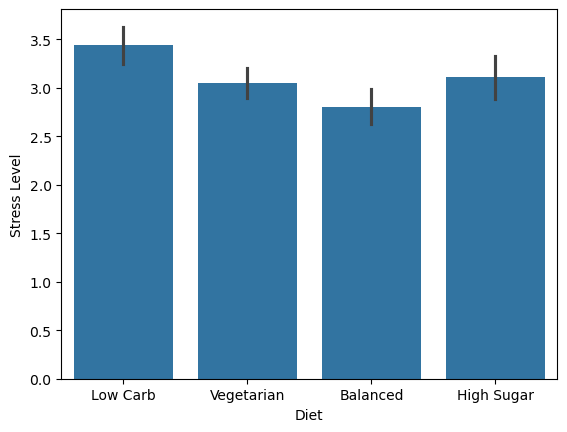

In [24]:
sns.barplot(data = df,x = 'Diet',y = 'Stress Level')

<Axes: xlabel='Symptoms', ylabel='Sleep Hours'>

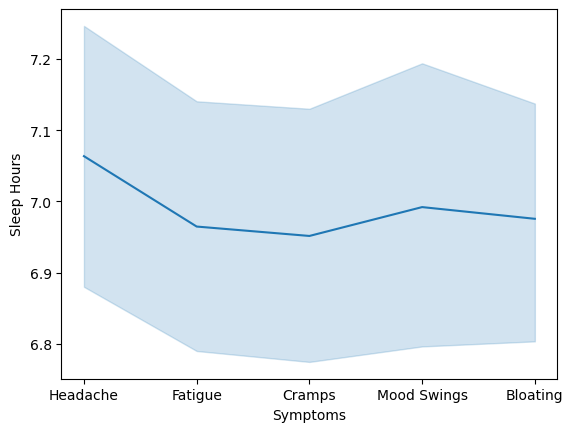

In [27]:
sns.lineplot(data = df,x = 'Symptoms',y = 'Sleep Hours')

In [30]:
df["Cycle Start Date"] = pd.to_datetime(df["Cycle Start Date"])

df["Start_Month"] = df["Cycle Start Date"].dt.month
df["Start_Year"] = df["Cycle Start Date"].dt.year

In [33]:
df["Prev_Period_Length"] = (
    df.groupby("User ID")["Period Length"].shift(1)
)

In [35]:
df["Prev_Cycle_Length"] = (
    df.groupby("User ID")["Cycle Length"].shift(1)
)

In [37]:
df["Prev_Symptom"] = (
    df.groupby("User ID")["Symptoms"].shift(1)
)

In [39]:
df["Avg_Cycle_Length"] = (
    df.groupby("User ID")["Cycle Length"]
      .transform(lambda x: x.shift(1).expanding().mean())
)

In [41]:
df["Avg_Period_Length"] = (
    df.groupby("User ID")["Period Length"]
      .transform(lambda x: x.shift(1).expanding().mean())
)

In [44]:
df.head()

,User ID,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms,Start_Month,Start_Year,Prev_Period_Length,Prev_Cycle_Length,Prev_Symptom,Avg_Cycle_Length,Avg_Period_Length
0,1,18,29.28,2,Moderate,5.4,Low Carb,2024-11-13 20:52:34.915012,26,7,2024-12-09 20:52:34.915012,Headache,11,2024,NaN,NaN,NaN,NaN,NaN
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09 20:52:34.915012,32,5,2025-01-10 20:52:34.915012,Fatigue,12,2024,7.0,26.0,Headache,26.0,7.000000
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10 20:52:34.915012,41,7,2025-02-20 20:52:34.915012,Fatigue,1,2025,5.0,32.0,Fatigue,29.0,6.000000
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20 20:52:34.915012,27,3,2025-03-19 20:52:34.915012,Fatigue,2,2025,7.0,41.0,Fatigue,33.0,6.333333
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19 20:52:34.915012,42,5,2025-04-30 20:52:34.915012,Cramps,3,2025,3.0,27.0,Fatigue,31.5,5.500000


In [54]:
df = df[df["Period_Count"] > 1].copy()

In [52]:
df["Period_Count"] = df.groupby("User ID").cumcount() + 0+1

In [56]:
df.shape

(795, 20)

In [58]:
df.head(5)

,User ID,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms,Start_Month,Start_Year,Prev_Period_Length,Prev_Cycle_Length,Prev_Symptom,Avg_Cycle_Length,Avg_Period_Length,Period_Count
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09 20:52:34.915012,32,5,2025-01-10 20:52:34.915012,Fatigue,12,2024,7.0,26.0,Headache,26.0,7.000000,2
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10 20:52:34.915012,41,7,2025-02-20 20:52:34.915012,Fatigue,1,2025,5.0,32.0,Fatigue,29.0,6.000000,3
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20 20:52:34.915012,27,3,2025-03-19 20:52:34.915012,Fatigue,2,2025,7.0,41.0,Fatigue,33.0,6.333333,4
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19 20:52:34.915012,42,5,2025-04-30 20:52:34.915012,Cramps,3,2025,3.0,27.0,Fatigue,31.5,5.500000,5
5,1,18,29.28,2,Moderate,5.4,Low Carb,2025-04-30 20:52:34.915012,41,5,2025-06-10 20:52:34.915012,Fatigue,4,2025,5.0,42.0,Cramps,33.6,5.400000,6


In [61]:
#########################################################################################################################################################

In [63]:
# so we are predicting both sympton and date of period

In [66]:
# regression for predicting date
y_reg = df["Period Length"]

In [68]:
features_reg = [
    "Age",
    "BMI",
    "Stress Level",
    "Exercise Frequency",
    "Sleep Hours",
    "Diet",
    "Period_Count",
    "Prev_Period_Length",
    "Prev_Cycle_Length",
    "Prev_Symptom",
    "Avg_Cycle_Length",
    "Avg_Period_Length"
]

X_reg = df[features_reg]

In [70]:
print(X_reg.shape)
print(y_reg.shape)

X_reg.head()

(795, 12)
(795,)


,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Period_Count,Prev_Period_Length,Prev_Cycle_Length,Prev_Symptom,Avg_Cycle_Length,Avg_Period_Length
1,18,29.28,2,Moderate,5.4,Low Carb,2,7.0,26.0,Headache,26.0,7.000000
2,18,29.28,2,Moderate,5.4,Low Carb,3,5.0,32.0,Fatigue,29.0,6.000000
3,18,29.28,2,Moderate,5.4,Low Carb,4,7.0,41.0,Fatigue,33.0,6.333333
4,18,29.28,2,Moderate,5.4,Low Carb,5,3.0,27.0,Fatigue,31.5,5.500000
5,18,29.28,2,Moderate,5.4,Low Carb,6,5.0,42.0,Cramps,33.6,5.400000


In [73]:
##############

In [75]:
# for sympton we will use classification

In [77]:
y_clf = df["Symptoms"]

In [79]:
features_clf = [
    "Age",
    "BMI",
    "Stress Level",
    "Exercise Frequency",
    "Sleep Hours",
    "Diet",
    "Period_Count",
    "Prev_Period_Length",
    "Prev_Cycle_Length",
    "Prev_Symptom",
    "Avg_Cycle_Length",
    "Avg_Period_Length"
]

X_clf = df[features_clf]

In [82]:
# splitting the data for regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg,y_reg,test_size = 0.2,random_state = 42)

In [85]:
# splitting data for classification

In [87]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split( X_clf,y_clf,test_size=0.2,random_state=42,stratify=y_clf)

In [90]:
# now lets classifyy the columns based on their type
numerical_features = [
    "Age",
    "BMI",
    "Stress Level",
    "Sleep Hours",
    "Period_Count",
    "Prev_Period_Length",
    "Prev_Cycle_Length",
    "Avg_Cycle_Length",
    "Avg_Period_Length"
]

categorical_features = [
    "Exercise Frequency",
    "Diet",
    "Prev_Symptom"
]

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [95]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [98]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

In [100]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'BMI', 'Stress Level', 'Sleep Hours',
                                  'Period_Count', 'Prev_Period_Length',
                                  'Prev_Cycle_Length', 'Avg_Cycle_Length',
                                  'Avg_Period_Length']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Exercise Frequency', 'Diet',
                                  'Prev_Symptom'])])

In [102]:
from sklearn.ensemble import RandomForestRegressor

reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [104]:
reg_pipeline.fit(
    X_reg_train,
    y_reg_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BMI', 'Stress Level',
                                                   'Sleep Hours',
                                                   'Period_Count',
                                                   'Prev_Period_Length',
                                                   'Prev_Cycle_Length',
                                                   'Avg_Cycle_Length',
                                                   'Avg_Period_Length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Exercise Frequency', 'Diet',
                                                   'Prev_Symptom'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [105]:
y_reg_pred = reg_pipeline.predict(X_reg_test)

In [108]:
print(y_reg_pred[:10])

[5.975 4.755 4.93  4.625 4.37  5.765 5.96  5.055 5.305 5.39 ]


In [110]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_reg_test.values,
    "Predicted": y_reg_pred
})

results.head(10)

,Actual,Predicted
0,6,5.975
1,6,4.755
2,6,4.930
3,7,4.625
4,4,4.370
5,4,5.765
6,7,5.960
7,7,5.055
8,7,5.305
9,6,5.390


In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.2192138364779876
RMSE: 1.420216178513219
R2  : -0.04517772351807836


In [114]:
reg_results = pd.DataFrame({
    "Actual_Period_Length": y_reg_test.values,
    "Predicted_Period_Length": y_reg_pred
})

reg_results["Predicted_Rounded"] = (
    reg_results["Predicted_Period_Length"].round().astype(int)
)

reg_results.head(10)

,Actual_Period_Length,Predicted_Period_Length,Predicted_Rounded
0,6,5.975,6
1,6,4.755,5
2,6,4.930,5
3,7,4.625,5
4,4,4.370,4
5,4,5.765,6
6,7,5.960,6
7,7,5.055,5
8,7,5.305,5
9,6,5.390,5


In [116]:
#########################################################################################################################################################

In [119]:
# now Classification model

In [121]:
from sklearn.ensemble import RandomForestClassifier

clf_pipeline = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [123]:
clf_pipeline.fit(
    X_clf_train,
    y_clf_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BMI', 'Stress Level',
                                                   'Sleep Hours',
                                                   'Period_Count',
                                                   'Prev_Period_Length',
                                                   'Prev_Cycle_Length',
                                                   'Avg_Cycle_Length',
                                                   'Avg_Period_Length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Exercise Frequency', 'Diet',
                                                   'Prev_Symptom'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [125]:
y_clf_pred = clf_pipeline.predict(X_clf_test)

In [127]:
print(y_clf_pred[:10])

['Cramps' 'Bloating' 'Bloating' 'Bloating' 'Bloating' 'Cramps' 'Cramps'
 'Fatigue' 'Bloating' 'Fatigue']


In [129]:
clf_results = pd.DataFrame({
    "Actual_Symptom": y_clf_test.values,
    "Predicted_Symptom": y_clf_pred
})

clf_results.head(15)

,Actual_Symptom,Predicted_Symptom
0,Cramps,Cramps
1,Cramps,Bloating
2,Cramps,Bloating
3,Fatigue,Bloating
4,Fatigue,Bloating
5,Fatigue,Cramps
6,Fatigue,Cramps
7,Bloating,Fatigue
8,Bloating,Bloating
9,Headache,Fatigue


In [132]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_clf_test,
    y_clf_pred
)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_clf_test,
        y_clf_pred
    )
)

Accuracy: 0.2641509433962264

Classification Report:
              precision    recall  f1-score   support

    Bloating       0.29      0.35      0.32        37
      Cramps       0.30      0.41      0.34        32
     Fatigue       0.21      0.18      0.20        33
    Headache       0.22      0.14      0.17        29
 Mood Swings       0.25      0.21      0.23        28

    accuracy                           0.26       159
   macro avg       0.25      0.26      0.25       159
weighted avg       0.26      0.26      0.26       159



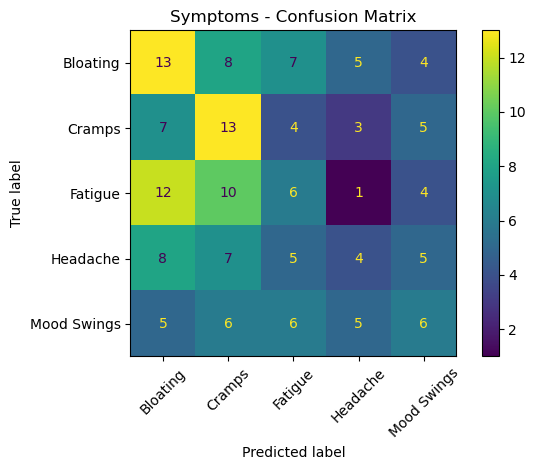

In [135]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_clf_test,
    y_clf_pred,
    xticks_rotation=45
)

plt.title("Symptoms - Confusion Matrix")
plt.tight_layout()
plt.show()

In [137]:
symptom_probabilities = clf_pipeline.predict_proba(X_clf_test)

print(symptom_probabilities[0])

[0.22  0.275 0.23  0.18  0.095]


In [139]:
classes = clf_pipeline.named_steps["model"].classes_

print(classes)

['Bloating' 'Cramps' 'Fatigue' 'Headache' 'Mood Swings']


In [141]:
prob_df = pd.DataFrame(
    symptom_probabilities,
    columns=classes
)

prob_df.head()

,Bloating,Cramps,Fatigue,Headache,Mood Swings
0,0.220,0.275,0.230,0.180,0.095
1,0.305,0.280,0.265,0.060,0.090
2,0.445,0.085,0.265,0.090,0.115
3,0.275,0.170,0.215,0.160,0.180
4,0.380,0.270,0.170,0.085,0.095


In [143]:
#########################################################################################################################################################

In [146]:
# comparing best reg model

In [148]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

for name, model in reg_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_reg_train, y_reg_train)

    pred = pipeline.predict(X_reg_test)

    mae = mean_absolute_error(y_reg_test, pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, pred))
    r2 = r2_score(y_reg_test, pred)

    print("\n", name)
    print("MAE :", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R2  :", round(r2, 3))


 Linear Regression
MAE : 1.185
RMSE: 1.391
R2  : -0.003

 Random Forest
MAE : 1.219
RMSE: 1.42
R2  : -0.045

 Gradient Boosting
MAE : 1.24
RMSE: 1.454
R2  : -0.095


In [151]:
#comparing best clf model

In [153]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import accuracy_score, f1_score

clf_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [155]:
for name, model in clf_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_clf_train, y_clf_train)

    pred = pipeline.predict(X_clf_test)

    accuracy = accuracy_score(y_clf_test, pred)

    f1 = f1_score(
        y_clf_test,
        pred,
        average="weighted"
    )

    print("\n", name)
    print("Accuracy:", round(accuracy, 3))
    print("F1 Score:", round(f1, 3))


 Logistic Regression
Accuracy: 0.189
F1 Score: 0.191

 Random Forest
Accuracy: 0.264
F1 Score: 0.255

 Gradient Boosting
Accuracy: 0.226
F1 Score: 0.223


In [157]:
import joblib

joblib.dump(
    reg_pipeline,
    "period_length_model.pkl"
)


['period_length_model.pkl']

In [160]:
joblib.dump(
    clf_pipeline,
    "symptom_model.pkl"
)

['symptom_model.pkl']

In [163]:
period_predictions = reg_pipeline.predict(X_reg_test)

In [165]:
symptom_predictions = clf_pipeline.predict(X_clf_test)

In [167]:
symptom_proba = clf_pipeline.predict_proba(X_clf_test)

symptom_confidence = symptom_proba.max(axis=1) * 100

In [169]:
print(symptom_predictions[:5])
print(symptom_confidence[:5])

['Cramps' 'Bloating' 'Bloating' 'Bloating' 'Bloating']
[27.5 30.5 44.5 27.5 38. ]


In [171]:
dashboard_df = df.copy()

X_dashboard = dashboard_df[features_reg]

dashboard_df["Predicted_Period_Length"] = (
    reg_pipeline.predict(X_dashboard)
)

dashboard_df["Predicted_Symptom"] = (
    clf_pipeline.predict(X_dashboard)
)

In [173]:
proba = clf_pipeline.predict_proba(X_dashboard)

dashboard_df["Symptom_Confidence"] = (
    proba.max(axis=1) * 100
)

In [175]:
dashboard_df["Predicted_Next_Cycle_Date"] = (
    pd.to_datetime(dashboard_df["Cycle Start Date"])
    +
    pd.to_timedelta(
        dashboard_df["Avg_Cycle_Length"].round(),
        unit="D"
    )
)

In [177]:
dashboard_df.to_csv(
    "menstrual_dashboard_predictions.csv",
    index=False
)

PermissionError: [Errno 13] Permission denied: 'menstrual_dashboard_predictions.csv'

In [213]:
self_care = {
    "Cramps": [
        "Use a warm compress",
        "Stay hydrated",
        "Take adequate rest",
        "Try gentle movement"
    ],

    "Fatigue": [
        "Get adequate sleep",
        "Stay hydrated",
        "Eat regular balanced meals",
        "Take adequate rest"
    ],

    "Headache": [
        "Stay hydrated",
        "Eat meals regularly",
        "Get adequate sleep",
        "Take breaks from prolonged screen use"
    ],

    "Bloating": [
        "Stay hydrated",
        "Eat smaller balanced meals",
        "Try gentle physical activity",
        "Avoid foods that personally worsen bloating"
    ],

    "Mood Swings": [
        "Maintain adequate sleep",
        "Eat regular balanced meals",
        "Try gentle exercise",
        "Practice relaxation and stress management"
    ]
}


rows = []

for symptom, precautions in self_care.items():
    for number, precaution in enumerate(precautions, start=1):
        rows.append({
            "Predicted_Symptom": symptom,
            "Point_No": number,
            "Precaution": "• " + precaution
        })


precautions_df = pd.DataFrame(rows)

precautions_df

,Predicted_Symptom,Point_No,Precaution
0,Cramps,1,• Use a warm compress
1,Cramps,2,• Stay hydrated
2,Cramps,3,• Take adequate rest
3,Cramps,4,• Try gentle movement
4,Fatigue,1,• Get adequate sleep
5,Fatigue,2,• Stay hydrated
6,Fatigue,3,• Eat regular balanced meals
7,Fatigue,4,• Take adequate rest
8,Headache,1,• Stay hydrated
9,Headache,2,• Eat meals regularly


In [221]:
precautions_df.to_csv(
    "symptom_precautions.csv",
    index=False
)